In [2]:
import pandas as pd

# loading the Excel
path = r"/content/drive/MyDrive/Agentic AI/AAI4ScienceHackathon.xlsx"
xls = pd.ExcelFile(path)

df = pd.read_excel(path, sheet_name=xls.sheet_names[0])

# Pick the key columns (adjust names if they differ slightly)
cols_wanted = [
    "How many tasks did you complete?",
    "Save your personal github gist, different link than one provided and paste that link with responses here for evaluation",
    "Do you want to be considered for co-authorship if selected?",
    "Consent for research use",
    "Jay",
    "Choose 1 winner for your assignment"
]

missing = [c for c in cols_wanted if c not in df.columns]
if not missing:
    sub = df[cols_wanted].copy()

    # Simple stats
    print("\nTask completion stats:")
    print(sub["How many tasks did you complete?"].describe())

    # How many provided a gist link?
    gist_col = "Save your personal github gist, different link than one provided and paste that link with responses here for evaluation"
    has_gist = sub[gist_col].astype(str).str.contains("http", case=False, na=False)
    print("\nGist link provided:", has_gist.sum(), "out of", len(sub))



Task completion stats:
count     44
unique     9
top        7
freq      15
Name: How many tasks did you complete?, dtype: int64

Gist link provided: 44 out of 44


In [3]:
import pandas as pd
import sys

path = "/content/drive/MyDrive/Agentic AI/AAI4ScienceHackathon.xlsx"
xls = pd.ExcelFile(path)

df = pd.read_excel(path, sheet_name=xls.sheet_names[0])

# Try fuzzy find by keywords (so you don't fight exact names)
def find_col(keyword: str):
    keyword = keyword.lower()
    matches = [c for c in df.columns if keyword in str(c).lower()]
    return matches[0] if matches else None

col_tasks = find_col("how many tasks")
col_gist  = find_col("github gist")
col_auth  = find_col("co-authorship")
col_cons  = find_col("consent")
col_jay   = find_col("jay")
col_win   = find_col("winner")


cols = [c for c in [col_tasks, col_gist, col_auth, col_cons, col_jay, col_win] if c is not None]
sub = df[cols].copy()

if col_tasks:
    sub[col_tasks] = pd.to_numeric(sub[col_tasks], errors="coerce")

if col_tasks:
    print("\nTask completion stats:")
    print(sub[col_tasks].describe())

if col_gist:
    has_link = sub[col_gist].astype(str).str.contains("http", case=False, na=False)
    print("\nGist link provided:", int(has_link.sum()), "out of", len(sub))



Task completion stats:
count    40.000000
mean      4.975000
std       1.874081
min       0.000000
25%       3.000000
50%       5.000000
75%       7.000000
max       7.000000
Name: How many tasks did you complete?, dtype: float64

Gist link provided: 44 out of 44


In [4]:
import re
gist_col = "Save your personal github gist, different link than one provided and paste that link with responses here for evaluation"

def extract_first_url(x):
    if pd.isna(x):
        return None
    m = re.search(r"https?://\S+", str(x))
    return m.group(0) if m else None

df["notebook_url"] = df[gist_col].apply(extract_first_url)
df[["notebook_url"]].head(10)

,notebook_url
0,https://colab.research.google.com/gist/knc6/d7...
1,https://colab.research.google.com/gist/pahi-26...
2,https://colab.research.google.com/gist/hariner...
3,https://colab.research.google.com/gist/pahi-26...
4,https://gist.github.com/dmpatel00/4b42bd5eded9...
5,https://colab.research.google.com/gist/hariner...
6,https://gist.github.com/veritasc2/ee68235996b6...
7,https://colab.research.google.com/gist/xpw1337...
8,https://colab.research.google.com/gist/whatnot...
9,https://colab.research.google.com/drive/14bWB6...


In [5]:
import numpy as np
import re

df = df.copy()
df["participant_id"] = [f"P{i:02d}" for i in range(1, len(df)+1)]

task_col = "How many tasks did you complete?"
TASKS = ["T1", "T2", "T3", "T4", "T5", "T6", "T7"]

def parse_tasks_completed(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"\d+", s)
    return float(m.group(0)) if m else np.nan

df["tasks_completed_num"] = df[task_col].apply(parse_tasks_completed)

df["tasks_completed_num"] = df["tasks_completed_num"].clip(0, 7).round().astype("Int64")

task_matrix = pd.DataFrame(0, index=df["participant_id"], columns=TASKS, dtype=int)

for pid, n in zip(df["participant_id"], df["tasks_completed_num"]):
    if pd.isna(n):
        continue
    task_matrix.loc[pid, TASKS[:int(n)]] = 1

task_matrix["tasks_completed"] = task_matrix[TASKS].sum(axis=1)

gist_col = "Save your personal github gist, different link than one provided and paste that link with responses here for evaluation"
df["has_gist"] = df[gist_col].astype(str).str.contains(r"https?://", case=False, na=False)

task_matrix["has_gist"] = df["has_gist"].values

task_matrix.head(10)

,T1,T2,T3,T4,T5,T6,T7,tasks_completed,has_gist
participant_id,,,,,,,,,
P01,1,1,1,0,0,0,0,3,True
P02,1,1,1,1,1,1,1,7,True
P03,1,1,1,1,1,1,1,7,True
P04,1,1,1,1,1,1,1,7,True
P05,1,1,1,1,0,0,0,4,True
P06,1,1,1,1,1,1,1,7,True
P07,1,1,1,1,1,0,0,5,True
P08,1,1,1,1,1,1,1,7,True
P09,1,1,1,1,1,1,0,6,True


In [6]:
def extract_first_url(x):
    if pd.isna(x):
        return None
    m = re.search(r"https?://\S+", str(x))
    return m.group(0).rstrip(").,]}>") if m else None

In [7]:
df["notebook_url"] = df[gist_col].apply(extract_first_url)
df[["participant_id", "notebook_url"]].head(10)

,participant_id,notebook_url
0,P01,https://colab.research.google.com/gist/knc6/d7...
1,P02,https://colab.research.google.com/gist/pahi-26...
2,P03,https://colab.research.google.com/gist/hariner...
3,P04,https://colab.research.google.com/gist/pahi-26...
4,P05,https://gist.github.com/dmpatel00/4b42bd5eded9...
5,P06,https://colab.research.google.com/gist/hariner...
6,P07,https://gist.github.com/veritasc2/ee68235996b6...
7,P08,https://colab.research.google.com/gist/xpw1337...
8,P09,https://colab.research.google.com/gist/whatnot...
9,P10,https://colab.research.google.com/drive/14bWB6...


In [8]:
import json, time

try:
    import requests
    HAVE_REQUESTS = True
except ImportError:
    import urllib.request
    HAVE_REQUESTS = False

In [9]:
def fetch_url_text(url, timeout=30):
    """Fetch URL content (text). Returns (ok, text_or_none)."""
    try:
        if HAVE_REQUESTS:
            r = requests.get(url, timeout=timeout, headers={"User-Agent":"Mozilla/5.0"})
            if r.status_code != 200:
                return False, None
            return True, r.text
        else:
            with urllib.request.urlopen(url, timeout=timeout) as resp:
                return True, resp.read().decode("utf-8", errors="ignore")
    except Exception:
        return False, None

In [10]:
def colab_gist_to_raw(url):
    """
    Convert:
    https://colab.research.google.com/gist/user/gistid/file.ipynb
    -->
    https://gist.githubusercontent.com/user/gistid/raw/file.ipynb
    """
    m = re.match(
        r"https://colab\.research\.google\.com/gist/([^/]+)/([^/]+)/(.+\.ipynb)",
        url
    )
    if not m:
        return None
    user, gist_id, fname = m.groups()
    return f"https://gist.githubusercontent.com/{user}/{gist_id}/raw/{fname}"


In [11]:
def colab_drive_to_export(url):
    """
    Convert:
    https://colab.research.google.com/drive/FILE_ID
    -->
    https://drive.google.com/uc?export=download&id=FILE_ID
    """
    m = re.match(r"https://colab\.research\.google\.com/drive/([^/?]+)", url)
    if not m:
        return None
    file_id = m.group(1)
    return f"https://drive.google.com/uc?export=download&id={file_id}"


In [12]:
def normalize_colab_download_url(url):
    """
    For public Colab links, appending ?download=1 typically returns the .ipynb JSON.
    Handles existing query params gracefully.
    """
    if "colab.research.google.com" not in url:
        return url
    # if already has '?', append with '&'
    joiner = "&" if "?" in url else "?"
    return url + joiner + "download=1"

In [13]:
def extract_gist_raw_ipynb_urls(gist_url, html_text):
    """
    From a gist HTML page, extract raw links to .ipynb files.
    We look for gist.githubusercontent.com raw links ending with .ipynb.
    """
    # raw links look like: https://gist.githubusercontent.com/<user>/<gistid>/raw/<hash>/<filename>.ipynb
    raw_links = re.findall(r"https://gist\.githubusercontent\.com/[^\s\"']+?\.ipynb", html_text)
    # de-dupe preserve order
    seen, out = set(), []
    for u in raw_links:
        if u not in seen:
            seen.add(u)
            out.append(u)
    return out

In [14]:
def notebook_text_from_ipynb_json(ipynb_json_text):
    """Extract concatenated text from notebook cells + outputs."""
    nb = json.loads(ipynb_json_text)
    parts = []
    for cell in nb.get("cells", []):
        src = cell.get("source", "")
        if isinstance(src, list):
            src = "".join(src)
        parts.append(src)

        for out in cell.get("outputs", []):
            # common fields: 'text', 'data' (with 'text/plain')
            if "text" in out:
                t = out["text"]
                if isinstance(t, list):
                    t = "".join(t)
                parts.append(str(t))
            if "data" in out and isinstance(out["data"], dict):
                if "text/plain" in out["data"]:
                    t = out["data"]["text/plain"]
                    if isinstance(t, list):
                        t = "".join(t)
                    parts.append(str(t))
    return "\n".join(parts)

In [15]:
TASKS = ["T1","T2","T3","T4","T5","T6","T7"]

TASK_MARKERS = {
    # tool-grounded tasks
    "T1": [r"Task\s*1", r"get_weather", r"weather", r"Baltimore"],
    "T2": [r"Task\s*2", r"JARVIS", r"jarvis", r"DFT"],
    "T3": [r"Task\s*3", r"arXiv", r"arxiv"],

    # reasoning tasks (based on your official notebook text)
    "T4": [r"Task\s*4", r"Answer\s*:\s*240", r"\b240\b"],
    "T5": [r"Task\s*5", r"Answer\s*:\s*204", r"\b204\b"],
    "T6": [r"Task\s*6", r"optimization", r"maximize|minimize", r"constraint"],

    # failure mode / mitigation
    "T7": [r"Task\s*7", r"failure mode", r"hallucination", r"tool[-\s]?calling", r"agentic"],
}

def detect_task_flags(text):
    flags = {}
    for t in TASKS:
        pats = TASK_MARKERS[t]
        flags[t] = int(any(re.search(p, text, flags=re.IGNORECASE) for p in pats))
    return flags

In [16]:
def fetch_notebook_ipynb_text(url):
    if not isinstance(url, str) or not url.startswith("http"):
        return False, None, "no_url"

    # Case 1: Colab GIST
    raw = colab_gist_to_raw(url)
    if raw:
        ok, txt = fetch_url_text(raw)
        if ok and txt and txt.lstrip().startswith("{"):
            return True, txt, "colab_gist_raw"
        return False, None, "colab_gist_raw_failed"

    # Case 2: Colab DRIVE
    raw = colab_drive_to_export(url)
    if raw:
        ok, txt = fetch_url_text(raw)
        if ok and txt and txt.lstrip().startswith("{"):
            return True, txt, "colab_drive_export"
        return False, None, "colab_drive_export_failed"

    # Case 3: GitHub GIST page
    if "gist.github.com" in url:
        ok, html = fetch_url_text(url)
        if not ok or not html:
            return False, None, "gist_html_failed"
        raw_links = extract_gist_raw_ipynb_urls(url, html)
        if not raw_links:
            return False, None, "gist_no_ipynb_found"
        ok, txt = fetch_url_text(raw_links[0])
        if ok and txt and txt.lstrip().startswith("{"):
            return True, txt, "gist_raw_ipynb"
        return False, None, "gist_raw_fetch_failed"

    return False, None, "unsupported_url"

In [17]:
verified_rows = []

for pid, url in zip(df["participant_id"], df["notebook_url"]):
    ok, ipynb_text, src = fetch_notebook_ipynb_text(url)
    row = {"participant_id": pid, "notebook_url": url, "fetch_ok": int(ok), "fetch_source": src}

    if ok:
        full_text = notebook_text_from_ipynb_json(ipynb_text)
        row.update(detect_task_flags(full_text))
    else:
        row.update({t: 0 for t in TASKS})

    verified_rows.append(row)

verified = pd.DataFrame(verified_rows)
verified[["participant_id","fetch_ok","fetch_source"]].head(10)


,participant_id,fetch_ok,fetch_source
0,P01,1,colab_gist_raw
1,P02,1,colab_gist_raw
2,P03,0,colab_gist_raw_failed
3,P04,1,colab_gist_raw
4,P05,0,gist_no_ipynb_found
5,P06,1,colab_gist_raw
6,P07,0,gist_no_ipynb_found
7,P08,1,colab_gist_raw
8,P09,1,colab_gist_raw
9,P10,1,colab_drive_export


In [18]:
import os, json, re
import pandas as pd
from glob import glob

NOTEBOOK_DIR = "/mnt/data/notebooks"  # your folder

TASKS = ["T1","T2","T3","T4","T5","T6","T7"]

# --- Evidence patterns: match OUTPUTS primarily ---
EVIDENCE_OUTPUT_PATTERNS = {
    "T1": [r"current weather in", r"temperature", r"humidity", r"wind"],
    "T2": [r"jarvis", r"dft", r"total", r"materials", r"jid", r"JVASP"],
    "T3": [r"arxiv", r"arXiv:", r"title", r"authors", r"submitted", r"http"],
    "T4": [r"\b240\b"],
    "T5": [r"\b204\b"],
    "T6": [r"maximize|minimize", r"constraint", r"optimal", r"solution"],
    # T7 usually has no outputs; handled separately
}

def load_nb(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def cell_source(cell):
    src = cell.get("source", "")
    if isinstance(src, list):
        return "".join(src)
    return src or ""

def cell_outputs_text(cell):
    """Extract all text-like outputs from a cell."""
    outs = cell.get("outputs", [])
    parts = []
    for out in outs:
        if "text" in out:
            t = out["text"]
            if isinstance(t, list): t = "".join(t)
            parts.append(str(t))
        if "data" in out and isinstance(out["data"], dict):
            tp = out["data"].get("text/plain")
            if tp:
                if isinstance(tp, list): tp = "".join(tp)
                parts.append(str(tp))
    return "\n".join(parts)

def normalize(s):
    return re.sub(r"\s+", " ", (s or "")).strip().lower()

def find_task_start(cells, task_no):
    pat = re.compile(rf"\btask\s*{task_no}\b", re.IGNORECASE)
    for i, c in enumerate(cells):
        if pat.search(cell_source(c)):
            return i
    return None

def task_window(cells, start_idx, window=12):
    return cells[start_idx : min(len(cells), start_idx + window)]

def has_output_evidence(win_cells, patterns):
    text = "\n".join(cell_outputs_text(c) for c in win_cells)
    text_n = normalize(text)
    return any(re.search(p, text_n, re.IGNORECASE) for p in patterns) and len(text_n) > 20

def has_written_answer_evidence(win_cells, patterns):
    """Used for math tasks if they typed answer in a markdown/code cell but didn’t run."""
    text = "\n".join(cell_source(c) for c in win_cells)
    text_n = normalize(text)
    return any(re.search(p, text_n, re.IGNORECASE) for p in patterns) and len(text_n) > 50

# --- Task 7: evidence = participant wrote meaningful prose beyond template markers ---
def task7_written_prose(win_cells):
    text = "\n".join(cell_source(c) for c in win_cells)
    text_n = normalize(text)

    # Weak filter: must mention at least one failure-mode keyword
    if not re.search(r"hallucination|failure mode|verification|tool|grounding|stale", text_n):
        return False

    # And must have enough non-trivial text
    # (tune threshold if needed)
    return len(text_n) > 400

def score_notebook(ipynb_path):
    nb = load_nb(ipynb_path)
    cells = nb.get("cells", [])

    scores = {}
    for task_no, t in enumerate(TASKS, start=1):
        start = find_task_start(cells, task_no)
        if start is None:
            scores[t] = 0
            continue

        win = task_window(cells, start, window=12)

        # Tool tasks: outputs evidence
        if t in ["T1","T2","T3"]:
            scores[t] = 1 if has_output_evidence(win, EVIDENCE_OUTPUT_PATTERNS[t]) else 0

        # Math/optimization: outputs evidence OR written answer evidence
        elif t in ["T4","T5","T6"]:
            out_ok = has_output_evidence(win, EVIDENCE_OUTPUT_PATTERNS.get(t, []))
            write_ok = has_written_answer_evidence(win, EVIDENCE_OUTPUT_PATTERNS.get(t, []))
            scores[t] = 1 if (out_ok or write_ok) else 0

        # Failure-mode: prose evidence (not outputs)
        elif t == "T7":
            scores[t] = 1 if task7_written_prose(win) else 0

    return scores

files = sorted(glob(os.path.join(NOTEBOOK_DIR, "*.ipynb")))
rows = []
for i, f in enumerate(files, start=1):
    pid = f"P{i:02d}"
    try:
        s = score_notebook(f)  # should return dict with T1..T7
    except Exception as e:
        # if scoring crashes for any notebook, don't kill the whole run
        s = {t: 0 for t in TASKS}
        s["_error"] = str(e)

    # Force all task keys to exist
    for t in TASKS:
        s.setdefault(t, 0)

    rows.append({"participant_id": pid, "file": os.path.basename(f), **s})

task_df = pd.DataFrame(rows)

# print("Columns in task_df:", task_df.columns.tolist())
# # task_df.head(3)
# # test_file = files[0]
# # print("Testing:", test_file)
# # print(score_notebook(test_file))



In [19]:
import pandas as pd

path = "/content/drive/MyDrive/Agentic AI/task_completion_matrix.xlsx"   # <-- change filename if needed
df = pd.read_excel(path)

TASKS = ["T1","T2","T3","T4","T5","T6","T7"]

# Force numeric 0/1
for t in TASKS:
    df[t] = pd.to_numeric(df[t], errors="coerce").fillna(0).astype(int)

# Compute totals
df["tasks_completed_calc"] = df[TASKS].sum(axis=1)

# If your sheet already has tasks_completed, compare and show mismatches
if "tasks_completed" in df.columns:
    df["tasks_completed"] = pd.to_numeric(df["tasks_completed"], errors="coerce")
    mism = df[df["tasks_completed"] != df["tasks_completed_calc"]][["participant_id","file","tasks_completed","tasks_completed_calc"]]
    print("Mismatches (fix these rows in Excel or just trust calc):")
    print(mism.to_string(index=False))
else:
    df["tasks_completed"] = df["tasks_completed_calc"]

# Use calculated as source of truth
df["tasks_completed"] = df["tasks_completed_calc"]
df.drop(columns=["tasks_completed_calc"], inplace=True)

df.head(20)


Mismatches (fix these rows in Excel or just trust calc):
participant_id                           file  tasks_completed  tasks_completed_calc
           P06 aai4science_2025_kc (11).ipynb                3                     2
           P13 aai4science_2025_kc (18).ipynb                7                     6


,participant_id,file,T1,T2,T3,T4,T5,T6,T7,tasks_completed
0,P01,Copy_of_aai4science_2025_Huat.ipynb,1,1,1,1,1,1,0,6
1,P02,Yana_Propad_aai4science_2025_kc.ipynb,1,1,1,0,1,1,0,5
2,P03,aai4sci_akintola_kehinde.ipynb,1,1,0,0,0,0,0,2
3,P04,aai4science_2025_kc (1).ipynb,0,0,1,0,0,0,0,1
4,P05,aai4science_2025_kc (10).ipynb,1,1,1,0,0,0,0,3
5,P06,aai4science_2025_kc (11).ipynb,1,1,0,0,0,0,0,2
6,P07,aai4science_2025_kc (12).ipynb,1,1,1,0,0,0,0,3
7,P08,aai4science_2025_kc (13).ipynb,1,1,1,0,0,0,1,4
8,P09,aai4science_2025_kc (14).ipynb,1,1,1,1,1,1,1,7
9,P10,aai4science_2025_kc (15).ipynb,1,1,1,1,1,1,1,7


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plotting style (paper-safe)
sns.set(style="whitegrid", context="paper", font_scale=1.2)

# load data
path = "/content/drive/MyDrive/Agentic AI/task_completion_matrix.xlsx"
df = pd.read_excel(path)

TASKS = ["T1","T2","T3","T4","T5","T6","T7"]

# ensure numeric
for t in TASKS:
    df[t] = pd.to_numeric(df[t], errors="coerce").fillna(0).astype(int)

# recompute tasks_completed safely
df["tasks_completed"] = df[TASKS].sum(axis=1)

print("Loaded rows:", len(df))
df.head()

Loaded rows: 42


,participant_id,file,T1,T2,T3,T4,T5,T6,T7,tasks_completed
0,P01,Copy_of_aai4science_2025_Huat.ipynb,1,1,1,1,1,1,0,6
1,P02,Yana_Propad_aai4science_2025_kc.ipynb,1,1,1,0,1,1,0,5
2,P03,aai4sci_akintola_kehinde.ipynb,1,1,0,0,0,0,0,2
3,P04,aai4science_2025_kc (1).ipynb,0,0,1,0,0,0,0,1
4,P05,aai4science_2025_kc (10).ipynb,1,1,1,0,0,0,0,3


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
    rc={
        "axes.edgecolor": "0.2",
        "grid.color": "0.5"
    }
)


/tmp/ipython-input-4126120800.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


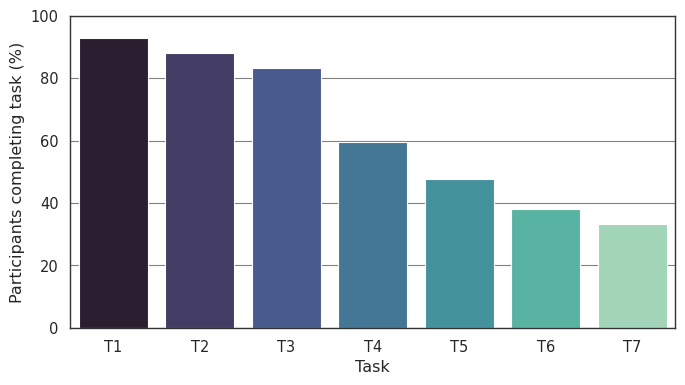

In [22]:
# palette = sns.color_palette("Set1", n_colors=len(TASKS))
palette = sns.color_palette("mako", n_colors=len(TASKS))

plt.figure(figsize=(7,4))
sns.barplot(
    x=TASKS,
    y=df[TASKS].mean().values * 100,
    palette=palette
)
plt.ylabel("Participants completing task (%)")
plt.xlabel("Task")
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Agentic AI/fig1_taskwise_completion.png", dpi=300)
plt.show()


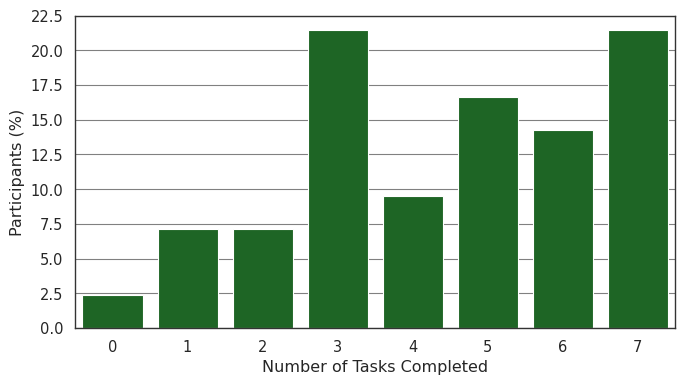

In [23]:
coverage = df["tasks_completed"].value_counts().sort_index()

plt.figure(figsize=(7,4))
sns.barplot(
    x=coverage.index,
    y=(coverage.values/len(df))*100,
    color=sns.color_palette("dark")[2]
)
plt.xlabel("Number of Tasks Completed")
plt.ylabel("Participants (%)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Agentic AI/fig2_participant_coverage.png", dpi=300)
plt.show()



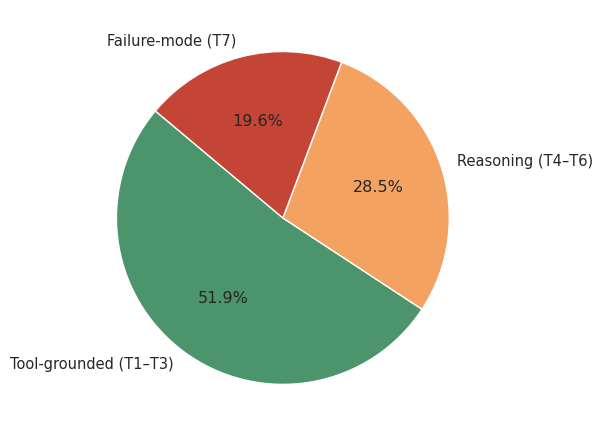

In [25]:
categories = {
    "Tool-grounded (T1–T3)": ["T1","T2","T3"],
    "Reasoning (T4–T6)": ["T4","T5","T6"],
    "Failure-mode (T7)": ["T7"],
}

cat_df = pd.DataFrame({
    "Category": list(categories.keys()),
    "Completion Rate (%)": [df[v].mean().mean()*100 for v in categories.values()]
})

labels = cat_df["Category"]
sizes = cat_df["Completion Rate (%)"]
colors = ["#4C956C", "#F4A261", "#C44536"]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/Agentic AI/fig3_category_completion_pie.png",
    dpi=300
)
plt.show()

In [ ]:
heatmap_df = df.sort_values("tasks_completed")[TASKS]

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_df,
    cmap="rocket",
    cbar_kws={"label": "Task Completed"},
    linewidths=0.3,
    linecolor="lightgray"
)
plt.xlabel("Task")
plt.ylabel("Participants (sorted by completion)")
plt.title("Task Completion Heatmap")
plt.tight_layout()
plt.savefig("fig4_task_heatmap.png", dpi=300)
plt.show()


In [ ]:
corr = df[TASKS].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap=sns.cubehelix_palette(as_cmap=True, reverse=True),
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Between Task Completions")
plt.tight_layout()
plt.savefig("fig5_task_correlation.png", dpi=300)
plt.show()
